# EEG Power Spectral Density (PSD)

This notebook shows how to estimate and visualise the **power spectral density** of a NeuraDock EEG recording using **Welch's method**, and how to read off the canonical EEG frequency bands.

**Important:** a clean spectrum requires clean data. Power-line pickup, muscle activity and electrode pops add broadband / 50 Hz energy that contaminates the PSD. So the pipeline here is:

> **load → quality check → drop bad segments → preprocess → PSD**

| Band | Frequency (Hz) | Typical association |
|------|----------------|---------------------|
| **Delta** | 0.5 – 4 | Deep sleep |
| **Theta** | 4 – 8 | Drowsiness, meditation |
| **Alpha** | 8 – 13 | Relaxed, eyes-closed (strong over occipital channels) |
| **Beta**  | 13 – 30 | Active thinking, focus |
| **Gamma** | 30 – 100 | High-level cognitive processing |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# NeuraDock helpers
from Neuradock_library import (
    text2data_bluetooth,             # raw .txt -> (7, N) array
    eeg_quality_check,               # per-segment quality metrics + diagnostics
    clean_eeg_data,                  # drop contaminated segments
    analyze_alpha_and_plot_eeg_group,  # one-call spectral analysis (spectrogram + SNR)
)

print('Libraries loaded.')

Libraries loaded.


## Step 1 — Load the recording

We use a resting-state recording, which has a clear occipital alpha peak. Any NeuraDock `.txt` file works.

In [2]:
fs = 250  # sampling rate (Hz)

eeg_raw = text2data_bluetooth('rest_20251024160452_2m12s.txt')
n_channels, n_points = eeg_raw.shape

print(f'Raw data shape : {eeg_raw.shape}')
print(f'Duration       : {n_points / fs:.1f} s')
print(f'Channels       : {n_channels}')

Raw data shape : (7, 33145)
Duration       : 132.6 s
Channels       : 7


## Step 2 — Quality check & remove bad segments

Before computing any spectrum we screen the recording for noise. `eeg_quality_check` splits the signal into **1-second segments** and scores each one on three metrics:

| Metric | Band / Rule | Threshold | Catches |
|--------|-------------|-----------|---------|
| **50 Hz power** | 49–51 Hz | `10` | Power-line interference |
| **EMG power**   | 20–40 Hz | `20` | Muscle activity |
| **Outlier count** | \|x\| ≥ 100 µV | `2` | Electrode pops / motion |

`clean_eeg_data` then **cuts out** the contaminated segments (and flags channels that are bad most of the time), returning a shorter but clean recording. Computing the PSD on this cleaned signal keeps artefact power out of the spectrum.

Applying bandpass filter (1-100Hz)...
Start processing data: 7 channels, 132 segments (250 points per segment)...


c:\Users\36254\anaconda3\envs\neuradock\Lib\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 2048 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


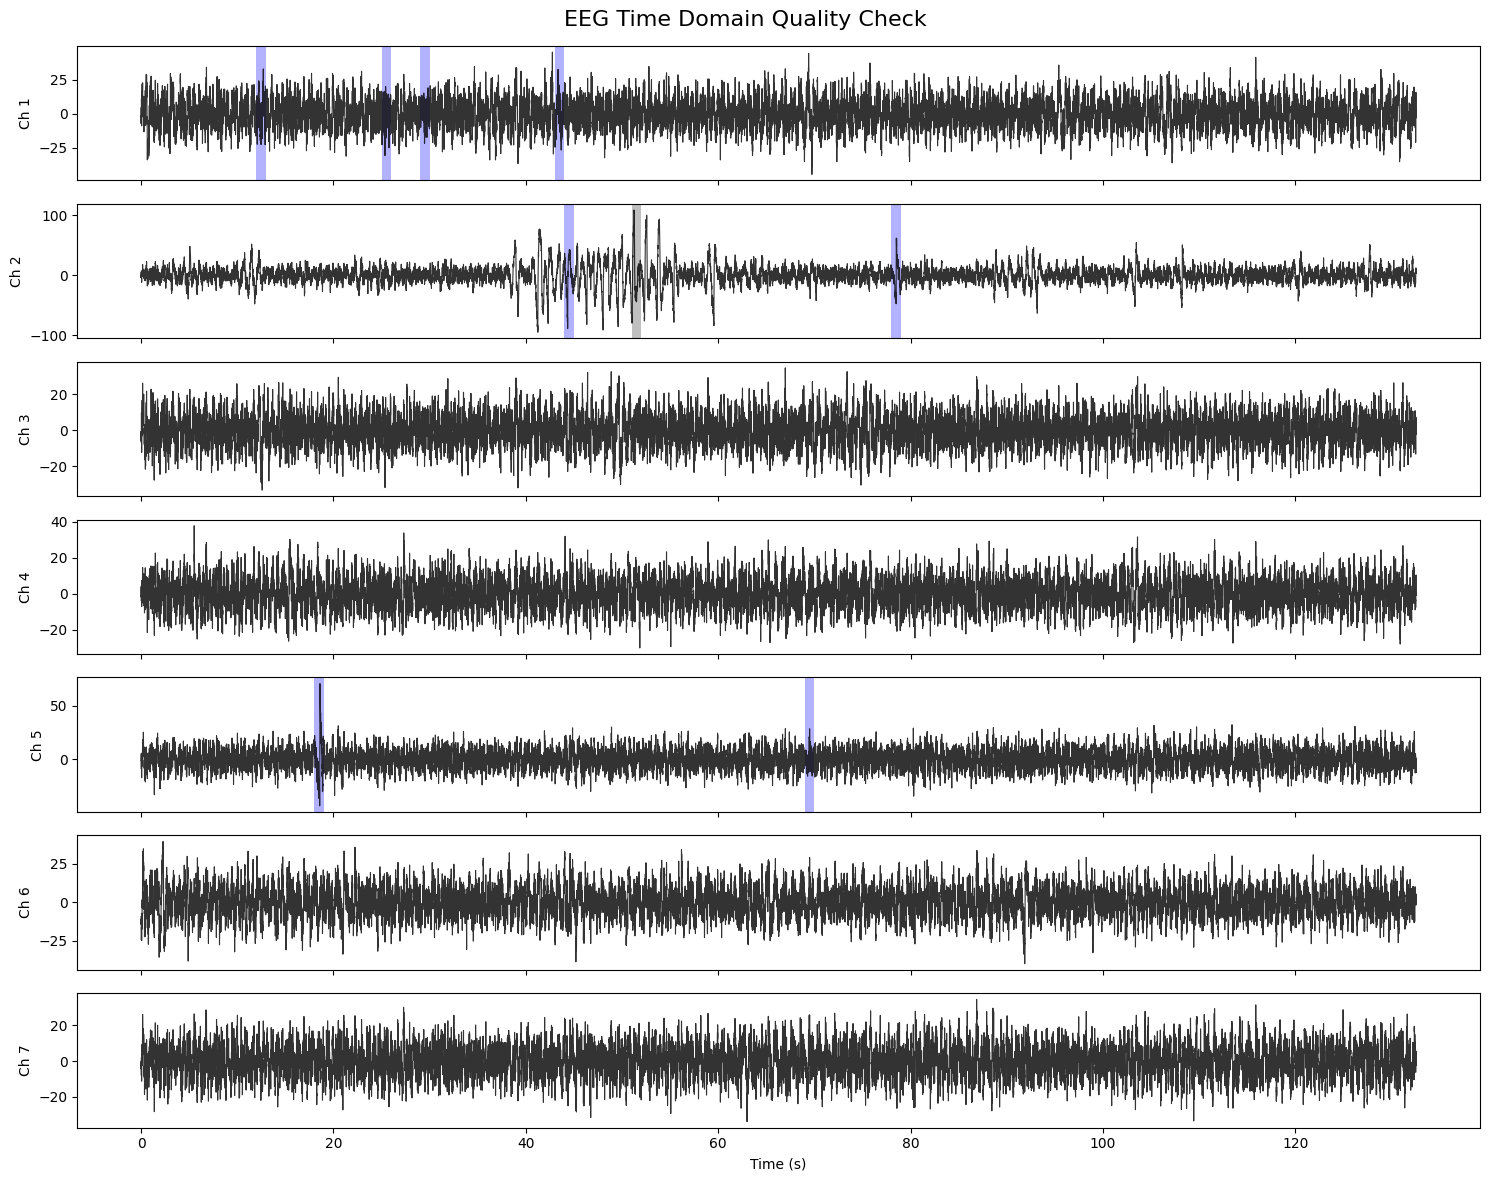

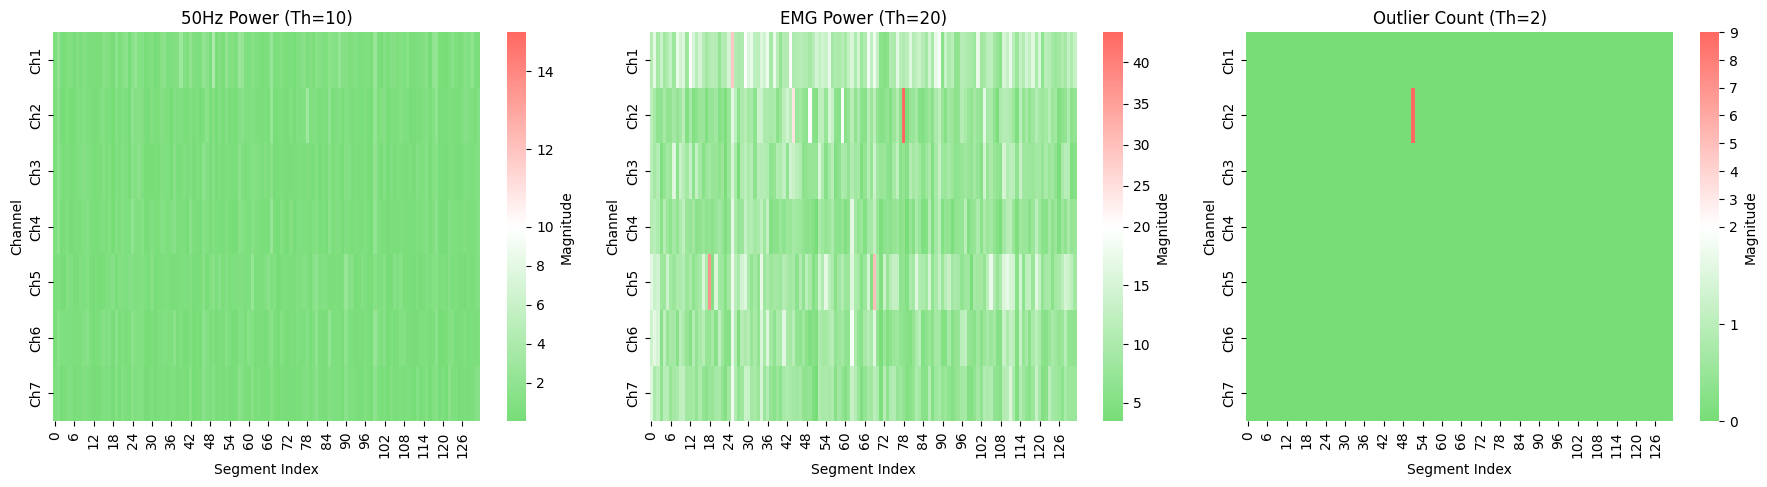

Detection results:
  - Bad channel indices (noise ratio > 40.0%): []
  - Good channel indices: [0 1 2 3 4 5 6]
Data cleaning complete: original length 33145 -> cleaned 30895
Information retention rate: 93.21%

Bad channels   : []
Retention rate : 93.2%
Clean length   : 30895 samples (123.6 s, was 132.6 s)


In [3]:
# Compute per-segment quality metrics (also draws time-domain + heatmap diagnostics)
metrics = eeg_quality_check(eeg_raw, fs=fs)

# Drop contaminated segments. thresh must match the values used inside eeg_quality_check.
thresh = [10, 20, 2]   # [50Hz, EMG, Outlier]
eeg_clean_raw, keep_mask, info = clean_eeg_data(
    eeg_raw, metrics, thresh,
    seg_len=250,        # 1-second segments
    bad_ch_ratio=0.4,   # > 40% bad  ->  bad channel
)

print()
print(f'Bad channels   : {info["bad_channels"]}')
print(f'Retention rate : {info["retention_rate"]:.1%}')
print(f'Clean length   : {eeg_clean_raw.shape[1]} samples '
      f'({eeg_clean_raw.shape[1] / fs:.1f} s, was {n_points / fs:.1f} s)')

> **Note:** `clean_eeg_data` concatenates the surviving segments, so there are small discontinuities at the splice points. For Welch PSD (which averages many short windows) this has a negligible effect compared with leaving the artefacts in.

## Step 3 — Preprocessing

On the cleaned signal we remove two remaining nuisances:

- a **50 Hz notch** to suppress any residual power-line component, and
- a **0.5–100 Hz band-pass** to remove DC drift and out-of-band noise.

Zero-phase `filtfilt` is used so the spectrum is not distorted by filter phase.

In [4]:
def preprocess_eeg(data, fs):
    """Notch (50 Hz) + band-pass (0.5-100 Hz), zero-phase."""
    b_notch, a_notch = signal.iirnotch(50.0, 30.0, fs)
    data = signal.filtfilt(b_notch, a_notch, data, axis=1)
    b_bp, a_bp = signal.butter(4, [0.5, 100.0], btype='bandpass', fs=fs)
    data = signal.filtfilt(b_bp, a_bp, data, axis=1)
    return data

eeg_clean = preprocess_eeg(eeg_clean_raw, fs)
print('Preprocessing complete. Clean & filtered shape:', eeg_clean.shape)

Preprocessing complete. Clean & filtered shape: (7, 30895)


## Step 4 — Welch PSD per channel

Welch's method splits the signal into overlapping windows, computes a periodogram on each, and averages them — trading a little frequency resolution for a much lower-variance estimate.

A **2-second Hann window with 50 % overlap** gives 0.5 Hz resolution, which is plenty to resolve the alpha peak.

In [5]:
nperseg = fs * 2     # 2-second window -> 0.5 Hz resolution
noverlap = fs        # 50% overlap

psd_all = []
for ch in range(n_channels):
    f, psd = signal.welch(eeg_clean[ch], fs, window='hann', nperseg=nperseg, noverlap=noverlap)
    psd_all.append(psd)
psd_all = np.array(psd_all)   # (n_channels, n_freqs)

print(f'PSD shape           : {psd_all.shape}')
print(f'Frequency resolution: {f[1] - f[0]:.2f} Hz')

PSD shape           : (7, 251)
Frequency resolution: 0.50 Hz


## Step 5 — Plot the spectra

We focus on 0–45 Hz (where almost all EEG rhythms live) and show both a linear and a log (dB) view. Watch for the **alpha bump around 10 Hz**.

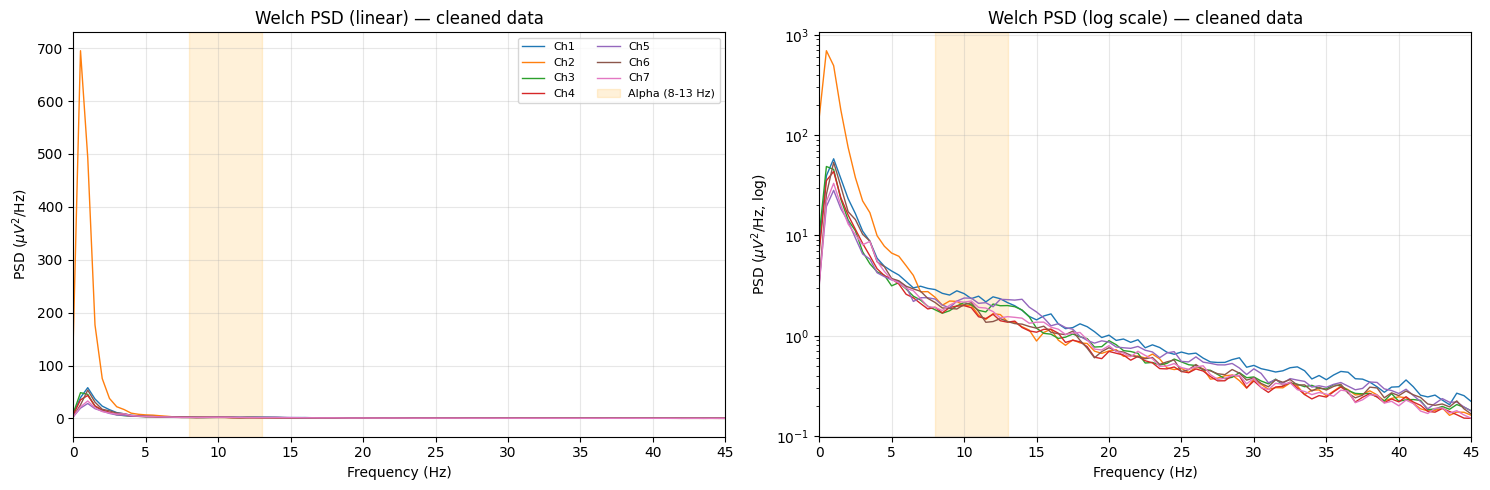

In [6]:
fmax = 45
band = f <= fmax

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for ch in range(n_channels):
    ax1.plot(f[band], psd_all[ch, band], label=f'Ch{ch+1}', lw=1.0)
    ax2.semilogy(f[band], psd_all[ch, band], label=f'Ch{ch+1}', lw=1.0)

for ax in (ax1, ax2):
    ax.axvspan(8, 13, color='orange', alpha=0.15, label='Alpha (8-13 Hz)')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_xlim(0, fmax)
    ax.grid(True, alpha=0.3)

ax1.set_ylabel('PSD ($\mu V^2$/Hz)')
ax1.set_title('Welch PSD (linear) — cleaned data')
ax2.set_ylabel('PSD ($\mu V^2$/Hz, log)')
ax2.set_title('Welch PSD (log scale) — cleaned data')
ax1.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Step 6 — Band power from the PSD

Integrating the PSD over a frequency band (numerically, with the trapezoid rule) gives the **absolute power** in that band. Dividing by the total power gives the **relative power**, which is easier to compare across channels and recordings.

C:\Users\36254\AppData\Local\Temp\ipykernel_21068\2326456260.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  band_p = np.trapz(psd_all[:, idx], f[idx], axis=1)
C:\Users\36254\AppData\Local\Temp\ipykernel_21068\2326456260.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_p = np.trapz(psd_all, f, axis=1)


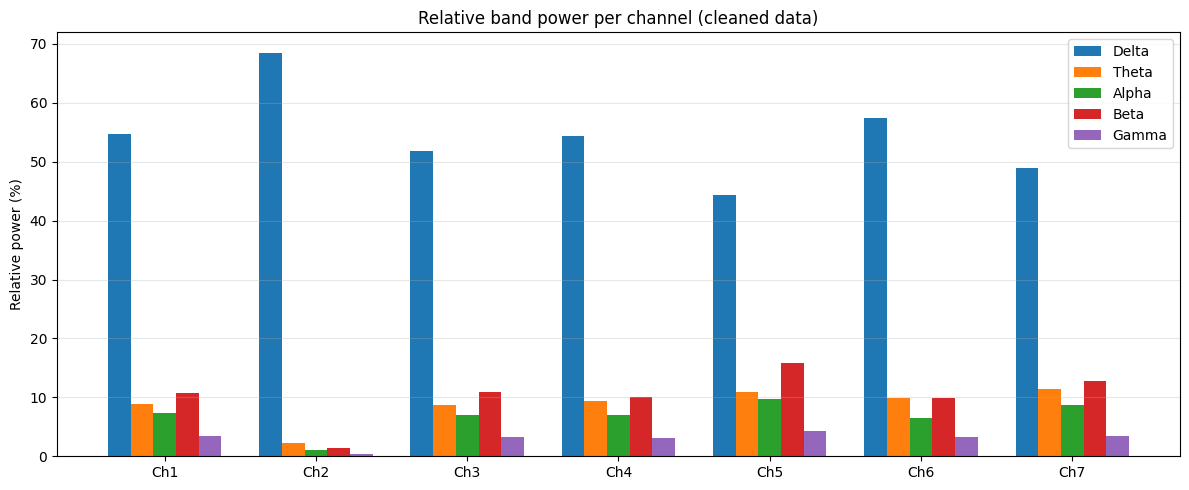

In [7]:
bands = {'Delta': (0.5, 4), 'Theta': (4, 8), 'Alpha': (8, 13),
         'Beta': (13, 30), 'Gamma': (30, 45)}

rel_power = np.zeros((n_channels, len(bands)))
for bi, (name, (lo, hi)) in enumerate(bands.items()):
    idx = (f >= lo) & (f < hi)
    band_p = np.trapz(psd_all[:, idx], f[idx], axis=1)
    total_p = np.trapz(psd_all, f, axis=1)
    rel_power[:, bi] = band_p / total_p

# Bar chart: relative band power per channel
x = np.arange(n_channels)
w = 0.15
plt.figure(figsize=(12, 5))
for bi, name in enumerate(bands):
    plt.bar(x + bi * w, rel_power[:, bi] * 100, width=w, label=name)
plt.xticks(x + 2 * w, [f'Ch{i+1}' for i in range(n_channels)])
plt.ylabel('Relative power (%)')
plt.title('Relative band power per channel (cleaned data)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7 — One-call spectral analysis (library)

`Neuradock_library` also ships a ready-made figure that combines the **time domain**, an **enhanced spectrogram** (time × frequency), zoomed alpha/resting snippets, and a per-channel **alpha-band SNR** bar chart — handy for a quick overview. We run it on the cleaned signal.

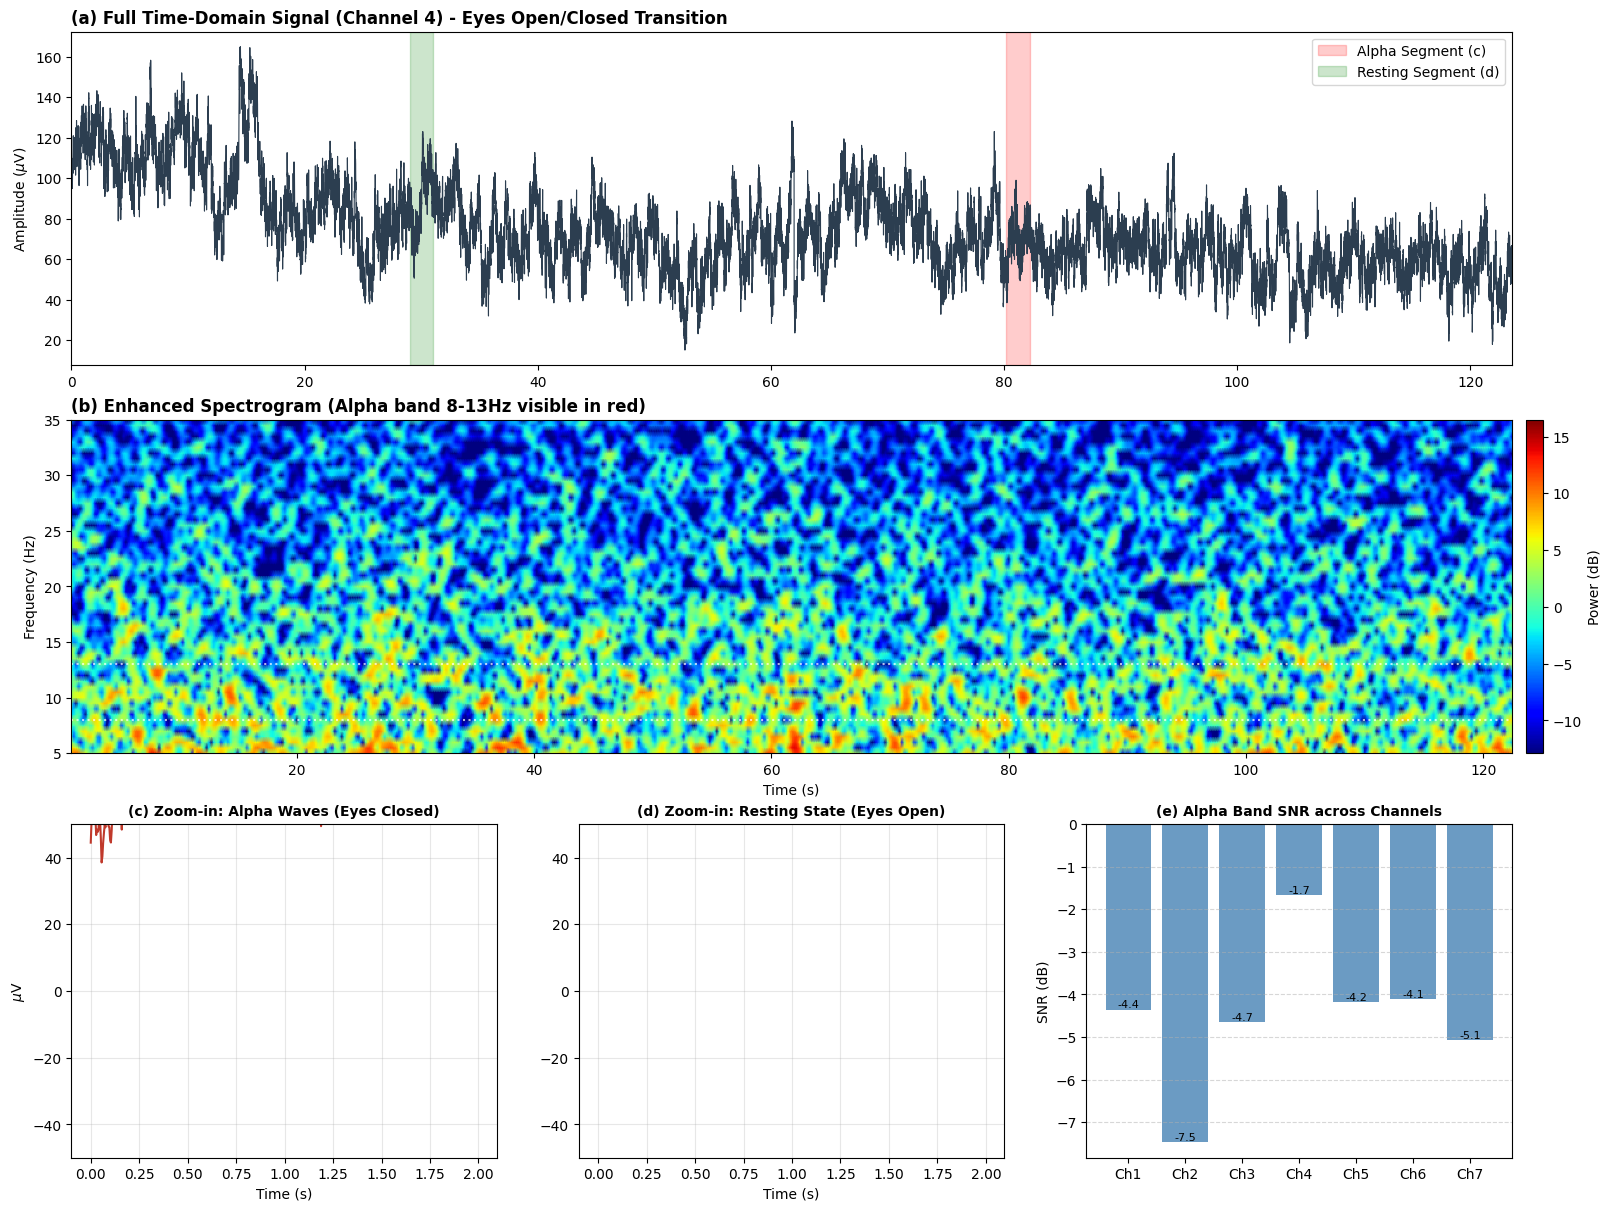

In [8]:
# show_channel picks the main channel for the time-domain & spectrogram panels
analyze_alpha_and_plot_eeg_group(eeg_clean_raw, fs=fs, show_channel=3)

## Notes

- **Quality first:** always screen and clean the recording before spectral analysis — a few seconds of 50 Hz pickup or muscle noise can dominate the PSD. See the sibling `../signal-quality-check` example for the cleaning step in detail.
- **Window length** trades resolution vs. variance: a longer `nperseg` resolves closely-spaced peaks but averages fewer windows (noisier). 2 s is a good default at 250 Hz.
- **Alpha** is strongest over occipital channels and increases when the eyes are closed — compare a `rest` (eyes-closed) vs. a `task` recording to see the difference.
- Use **relative** band power when comparing across channels/sessions, since absolute power depends on electrode impedance and gain.